<a href="https://colab.research.google.com/github/Tana497/mashin/blob/main/%D0%9B%D0%A02_%D0%9D%D0%BE%D0%B2%D0%BE%D1%81%D0%B0%D0%B4_%D0%A4%D0%86%D0%A24_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторна робота 2. Новосад Тетяна, ФІТ 4-8
---



# Завдання 1

**Була присутня на парі**

Обробка та нааліз даних про ВВП країн. Датасет було отримано з Вікіпедії з використанням бібілотеки Pandas.

1. Вивести перші 5 рядків датасета

In [2]:
import numpy as np
import pandas as pd
import requests

In [3]:
url = "https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)"
html = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}).text

tables = pd.read_html(html)
df = tables [2]
df.head()

/tmp/ipykernel_3513/1568175070.py:4: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html)


,Country/Territory,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211


In [4]:
df.columns

Index(['Country/Territory', 'IMF (2026)[1]', 'World Bank (2025)[6]',
       'United Nations (2024)[7]'],
      dtype='object')

2.	Визначити розмір датасета.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222 entries, 0 to 221
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Country/Territory         222 non-null    object
 1   IMF (2026)[1]             222 non-null    object
 2   World Bank (2025)[6]      222 non-null    object
 3   United Nations (2024)[7]  222 non-null    object
dtypes: object(4)
memory usage: 7.1+ KB


In [6]:
df.dtypes

,0
Country/Territory,object
IMF (2026)[1],object
World Bank (2025)[6],object
United Nations (2024)[7],object


 3.	Визначити оптимальну кількість стовпців (видалити зайві, на власний розсуд).

In [7]:
df.columns = (df.columns
              .str.replace(r'(?:\s*\[\d+\])+', '', regex=True)
              .str.replace('Country/Territory', 'Country', regex=False))
df

,Country,IMF (2026),World Bank (2025),United Nations (2024)
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211
...,...,...,...,...
217,Palau,377,345,310
218,Marshall Islands,342,308,281
219,Nauru,196,176,187
220,Montserrat,—N/a,—N/a,81


In [9]:
df = df.drop(df[df.iloc[:, 0] == "World"].index)
df

,Country,IMF (2026),World Bank (2025),United Nations (2024)
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211
5,United Kingdom,4264794,4002588,3685881
...,...,...,...,...
217,Palau,377,345,310
218,Marshall Islands,342,308,281
219,Nauru,196,176,187
220,Montserrat,—N/a,—N/a,81


4.	Замініть у таблиці значення "—" на значення NaN. Перевірити наявність пропущених значень. При наявності, замінити пропущені значення на середнє значення.

In [10]:
df.isnull().sum()

,0
Country,0
IMF (2026),0
World Bank (2025),0
United Nations (2024),0


In [13]:
df['IMF (2026)'] = pd.to_numeric(df['IMF (2026)'], errors='coerce')
df['World Bank (2025)'] = pd.to_numeric(df['World Bank (2025)'], errors='coerce')
df['United Nations (2024)'] = pd.to_numeric(df['United Nations (2024)'], errors='coerce')

In [15]:
df.dtypes

,0
Country,object
IMF (2026),float64
World Bank (2025),float64
United Nations (2024),float64


In [16]:
df

,Country,IMF (2026),World Bank (2025),United Nations (2024)
1,United States,32383920.0,30769700.0,29298000.0
2,China[n 1],20851593.0,19498039.0,18743802.0
3,Germany,5452858.0,5050923.0,4659929.0
4,Japan,4379253.0,4435163.0,4026211.0
5,United Kingdom,4264794.0,4002588.0,3685881.0
...,...,...,...,...
217,Palau,377.0,345.0,310.0
218,Marshall Islands,342.0,308.0,281.0
219,Nauru,196.0,176.0,187.0
220,Montserrat,NaN,NaN,81.0


In [17]:
df.isnull().sum()

,0
Country,0
IMF (2026),31
World Bank (2025),35
United Nations (2024),9


In [18]:
df.iloc[:, 1:] = df.iloc[:, 1:].apply(lambda x: x.fillna(x.mean()), axis=1)

df.isnull().sum()

,0
Country,0
IMF (2026),8
World Bank (2025),8
United Nations (2024),8


In [19]:
part = df.iloc[:, 1:]

row_filled = part.apply(lambda r: r.fillna(r.mean()), axis=1)
col_means = part.mean()

df.iloc[:, 1:] = row_filled.fillna(col_means)

df.isnull().sum()

,0
Country,0
IMF (2026),0
World Bank (2025),0
United Nations (2024),0


5. Ще раз вивести датасет

In [20]:
df.tail()

,Country,IMF (2026),World Bank (2025),United Nations (2024)
217,Palau,377.0,345.0,310.0
218,Marshall Islands,342.0,308.0,281.0
219,Nauru,196.0,176.0,187.0
220,Montserrat,81.0,81.0,81.0
221,Tuvalu,65.0,57.0,56.0


6.	Перевірити наявність дублікатів. При наявності видалити дублікати.

In [21]:
df.duplicated().sum()

np.int64(0)

7.	Вивести описову статистику датасету describe()

In [22]:
df.describe()

,IMF (2026),World Bank (2025),United Nations (2024)
count,2.210000e+02,2.210000e+02,2.210000e+02
mean,5.943385e+05,5.561409e+05,5.246237e+05
std,2.673673e+06,2.527950e+06,2.410273e+06
min,6.500000e+01,5.700000e+01,5.600000e+01
25%,9.442000e+03,9.233000e+03,8.840000e+03
50%,4.884900e+04,4.809900e+04,4.276500e+04
75%,3.773650e+05,3.348550e+05,2.986970e+05
max,3.238392e+07,3.076970e+07,2.929800e+07


8. Визначте відхилення (різницю) між показниками IMF (2026) та World Bank (2025) для кожної країни. У яких країнах ці показники найбільше відрізняються (дати відповідь)?

In [23]:
df['IMF_WB_Diff'] = abs(df['IMF (2026)'] - df['World Bank (2025)'])

max_diff = df['IMF_WB_Diff'].max()

country = df[df['IMF_WB_Diff'] == max_diff]['Country'].values[0]
print(f'{country} has the largest difference between IMF and WB: {max_diff}')

df.head(10)

United States has the largest difference between IMF and WB: 1614220.0


,Country,IMF (2026),World Bank (2025),United Nations (2024),IMF_WB_Diff
1,United States,32383920.0,30769700.0,29298000.0,1614220.0
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0
3,Germany,5452858.0,5050923.0,4659929.0,401935.0
4,Japan,4379253.0,4435163.0,4026211.0,55910.0
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0
6,India,4153191.0,3956067.0,3952244.0,197124.0
7,France,3596094.0,3366316.0,3160443.0,229778.0
8,Italy,2738164.0,2551557.0,2380825.0,186607.0
9,Russia,2656452.0,2561310.0,2173386.0,95142.0
10,Brazil,2635912.0,2279920.0,2185822.0,355992.0


9.	Обчисліть кореляцію між показниками IMF (2026), World Bank (2025) та United Nations (2024). Які пари змінних мають найвищу кореляцію?

In [24]:
# Calculate correlation between IMF and WB and UN
cor_IMF_WB = df['IMF (2026)'].corr(df['World Bank (2025)'])
cor_IMF_UN = df['IMF (2026)'].corr(df['United Nations (2024)'])
cor_WB_UN = df['World Bank (2025)'].corr(df['United Nations (2024)'])

print(f'Correlation between IMF and WB: {cor_IMF_WB}')
print(f'Correlation between IMF and UN: {cor_IMF_UN}')
print(f'Correlation between  WB and UN: {cor_WB_UN}')

Correlation between IMF and WB: 0.9998772853399375
Correlation between IMF and UN: 0.9998162531253877
Correlation between  WB and UN: 0.9998603541665632


In [25]:
# Find highest correlation
max_cor = max(cor_IMF_WB, cor_IMF_UN, cor_WB_UN)
if max_cor == cor_IMF_WB:
    print('IMF and WB have the highest correlation')
elif max_cor == cor_IMF_UN:
    print('IMF and UN have the highest correlation')
else:
    print('WB and UN have the highest correlation')

IMF and WB have the highest correlation


Обчислити середнє значення за стовпцями

In [26]:
mean_IMF = df['IMF (2026)'].mean()
mean_IMF

np.float64(594338.5211267605)

In [27]:
mean_WB = df['World Bank (2025)'].mean()
mean_WB

np.float64(556140.9014084507)

In [28]:
mean_UN = df['United Nations (2024)'].mean()
mean_UN

np.float64(524623.7323943662)

11.	Обчисліть стандартне відхилення показників для кожної країни. Яка країна має найвищу варіативність у показниках між роками?

In [29]:
df['std'] = df.iloc[:, 1:].std(axis=1)

max_std = df['std'].max()
country = df[df['std'] == max_std]['Country'].values[0]
print(f'{country} has the highest standard deviation: {max_std}')

df.head(10)

United States has the highest standard deviation: 14655779.964896671


,Country,IMF (2026),World Bank (2025),United Nations (2024),IMF_WB_Diff,std
1,United States,32383920.0,30769700.0,29298000.0,1614220.0,1.465578e+07
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0,9.213488e+06
3,Germany,5452858.0,5050923.0,4659929.0,401935.0,2.348734e+06
4,Japan,4379253.0,4435163.0,4026211.0,55910.0,2.119895e+06
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0,1.876098e+06
6,India,4153191.0,3956067.0,3952244.0,197124.0,1.913990e+06
7,France,3596094.0,3366316.0,3160443.0,229778.0,1.582291e+06
8,Italy,2738164.0,2551557.0,2380825.0,186607.0,1.194072e+06
9,Russia,2656452.0,2561310.0,2173386.0,95142.0,1.202576e+06
10,Brazil,2635912.0,2279920.0,2185822.0,355992.0,1.024125e+06


12.	Визначення країни з найвищим та найнижчим показниками: Знайдіть країну з найвищим та найнижчим показниками у кожному з років (IMF (2026), World Bank (2025), United Nations (2024)).

In [30]:
columns = ['IMF (2026)', 'World Bank (2025)', 'United Nations (2024)']

for col in columns:
    max_row = df.loc[df[col].idxmax()]
    min_row = df.loc[df[col].idxmin()]

    print(f"=== {col} ===")
    print(f"Найвищий показник:  {max_row['Country']} — {max_row[col]:,.2f}")
    print(f"Найнижчий показник: {min_row['Country']} — {min_row[col]:,.2f}\n")

=== IMF (2026) ===
Найвищий показник:  United States — 32,383,920.00
Найнижчий показник: Tuvalu — 65.00

=== World Bank (2025) ===
Найвищий показник:  United States — 30,769,700.00
Найнижчий показник: Tuvalu — 57.00

=== United Nations (2024) ===
Найвищий показник:  United States — 29,298,000.00
Найнижчий показник: Tuvalu — 56.00



13.	Побудуйте гістограму для розподілу показників IMF (2026) серед всіх країн. Який вигляд має розподіл? Чи є країни, що виділяються?

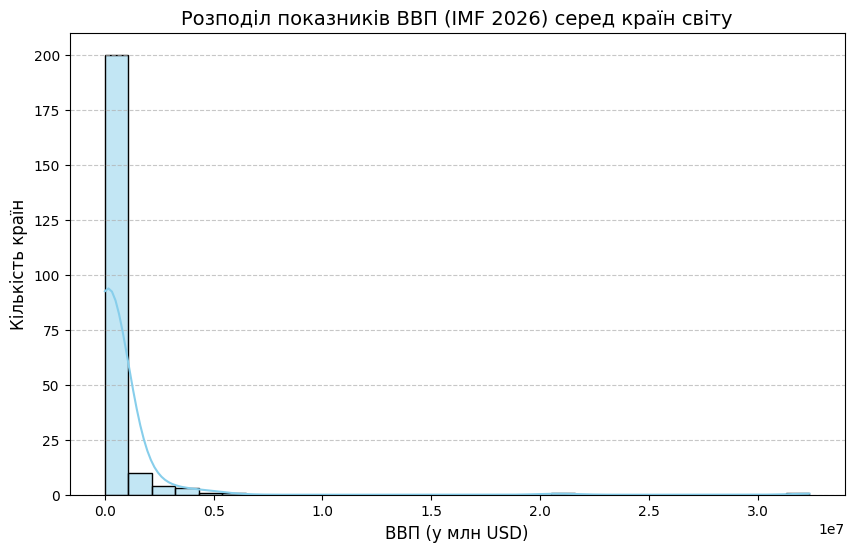

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Налаштування стилю
plt.figure(figsize=(10, 6))

# Побудова гістограми з лінією щільності (KDE)
sns.histplot(df['IMF (2026)'], bins=30, kde=True, color='skyblue', edgecolor='black')

plt.title('Розподіл показників ВВП (IMF 2026) серед країн світу', fontsize=14)
plt.xlabel('ВВП (у млн USD)', fontsize=12)
plt.ylabel('Кількість країн', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

14.	Розрахуйте частку кожної країни в загальному значенні для кожного року (IMF (2026), World Bank (2025), United Nations (2024)).
 Як змінюються частки країн з часом (дати відповідь)?

In [32]:
gdp_cols = ['IMF (2026)', 'World Bank (2025)', 'United Nations (2024)']

for col in gdp_cols:
    share_col_name = f'{col}_Share (%)'
    df[share_col_name] = (df[col] / df[col].sum()) * 100

share_cols = [f'{col}_Share (%)' for col in gdp_cols]
df[['Country'] + share_cols].head(10)

,Country,IMF (2026)_Share (%),World Bank (2025)_Share (%),United Nations (2024)_Share (%)
1,United States,24.654901,25.034917,25.269565
2,China[n 1],15.874976,15.864041,16.166555
3,Germany,4.151433,4.109544,4.019195
4,Japan,3.334064,3.608548,3.472613
5,United Kingdom,3.246922,3.256595,3.179077
6,India,3.161955,3.218745,3.408816
7,France,2.737820,2.738910,2.725886
8,Italy,2.084651,2.076004,2.053465
9,Russia,2.022441,2.083939,1.874548
10,Brazil,2.006803,1.854994,1.885274


15.	Візуалізуйте зміни в показниках для кожної країни за три роки на графіку. Які країни показують стабільне зростання або спад (дати відповідь)?

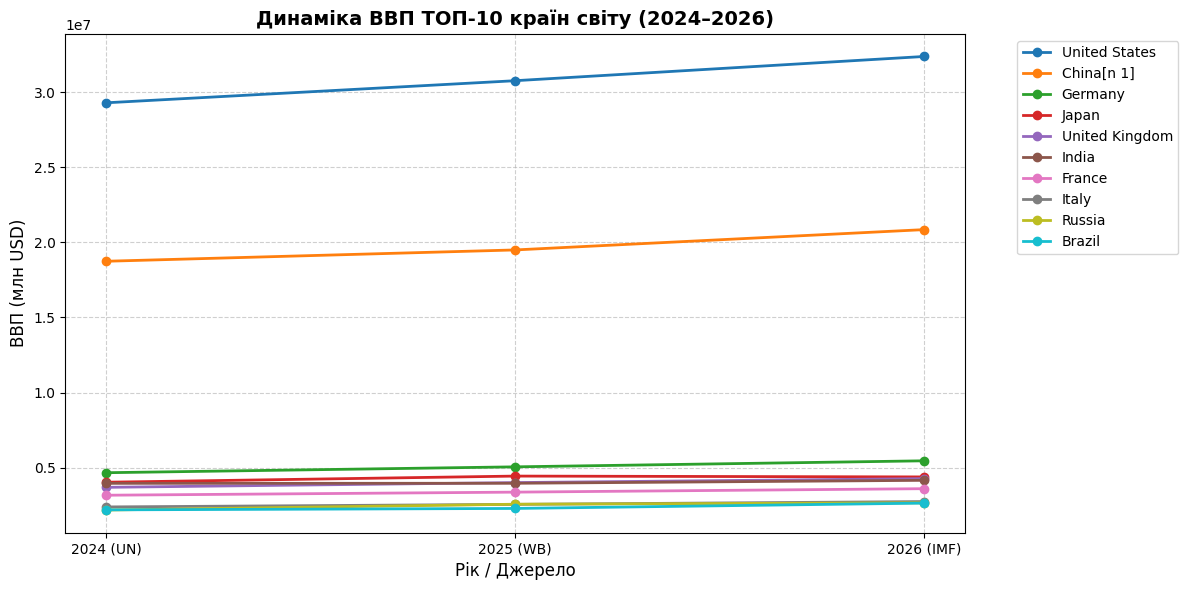

In [33]:
top10 = df.nlargest(10, 'IMF (2026)').copy()

years = ['2024 (UN)', '2025 (WB)', '2026 (IMF)']
data_to_plot = top10.set_index('Country')[['United Nations (2024)', 'World Bank (2025)', 'IMF (2026)']]
data_to_plot.columns = years

plt.figure(figsize=(12, 6))

for country in data_to_plot.index:
    plt.plot(years, data_to_plot.loc[country], marker='o', linewidth=2, label=country)

plt.title('Динаміка ВВП ТОП-10 країн світу (2024–2026)', fontsize=14, fontweight='bold')
plt.xlabel('Рік / Джерело', fontsize=12)
plt.ylabel('ВВП (млн USD)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()